# Multiclass Classification

These models can classifiy into multiple outputs. `y` can have more than 2 values.

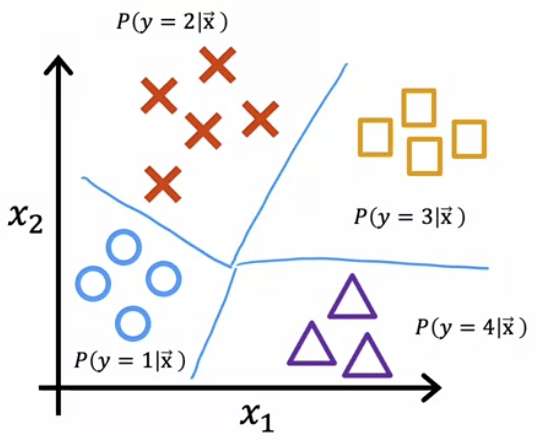

# 1 - Softmax

When there are 2 possible values.

- If the probability that $a = 1$ is `0.7`.
- Then the probability that $a = 0$ is `0.3`.
- This is because $0.7 + 0.3 = 1$.
- The totals sum of all probabilitites should always be `1.0`.

This applies when there are more than 2 potential outputs.

## 1.2 - Softmax Formula

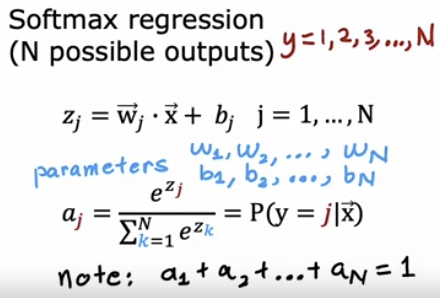

### Example:

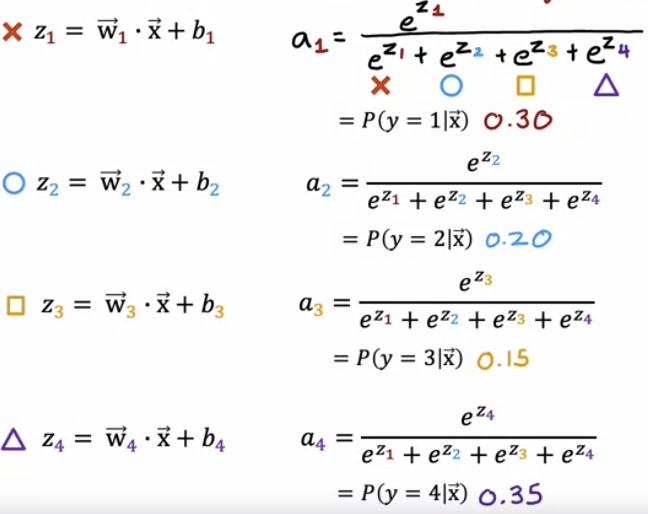

## 1.3 - Softmax Cost Function

For a given data node `{x: 12.31, y = "SELL"}`, calculate the probability that `x` is `SELL`. The cost is the difference between the the `probability` and `1`.

The loss function associated with Softmax, the cross-entropy loss, is:
\begin{equation}
  L(\mathbf{a},y)=\begin{cases}
    -log(a_1), & \text{if $y=1$}.\\
        &\vdots\\
     -log(a_N), & \text{if $y=N$}
  \end{cases} \tag{3}
\end{equation}

Where y is the target category for this example and $\mathbf{a}$ is the output of a softmax function. In particular, the values in $\mathbf{a}$ are probabilities that sum to one.
>**Recall:** In this course, Loss is for one example while Cost covers all examples. 
 
 
Note in (3) above, only the line that corresponds to the target contributes to the loss, other lines are zero. To write the cost equation we need an 'indicator function' that will be 1 when the index matches the target and zero otherwise. 
    $$\mathbf{1}\{y == n\} = =\begin{cases}
    1, & \text{if $y==n$}.\\
    0, & \text{otherwise}.
  \end{cases}$$
Now the cost is:
\begin{align}
J(\mathbf{w},b) = -\frac{1}{m} \left[ \sum_{i=1}^{m} \sum_{j=1}^{N}  1\left\{y^{(i)} == j\right\} \log \frac{e^{z^{(i)}_j}}{\sum_{k=1}^N e^{z^{(i)}_k} }\right] \tag{4}
\end{align}

Where $m$ is the number of examples, $N$ is the number of outputs. This is the average of all the losses.


## 1.4 - Softmax Output Layer

The number of neurons in the output layer is the same as the number of potential outputs.

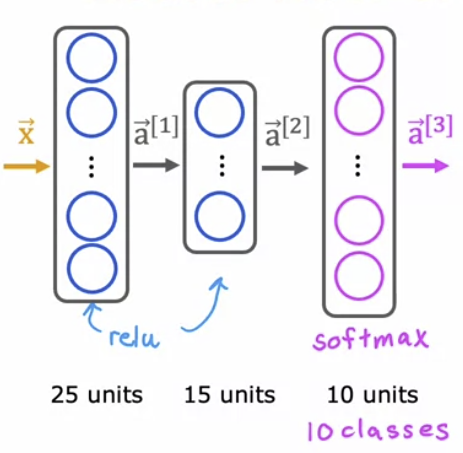

### 1.4.1 - Outputs Can Be Scalar Or Vector

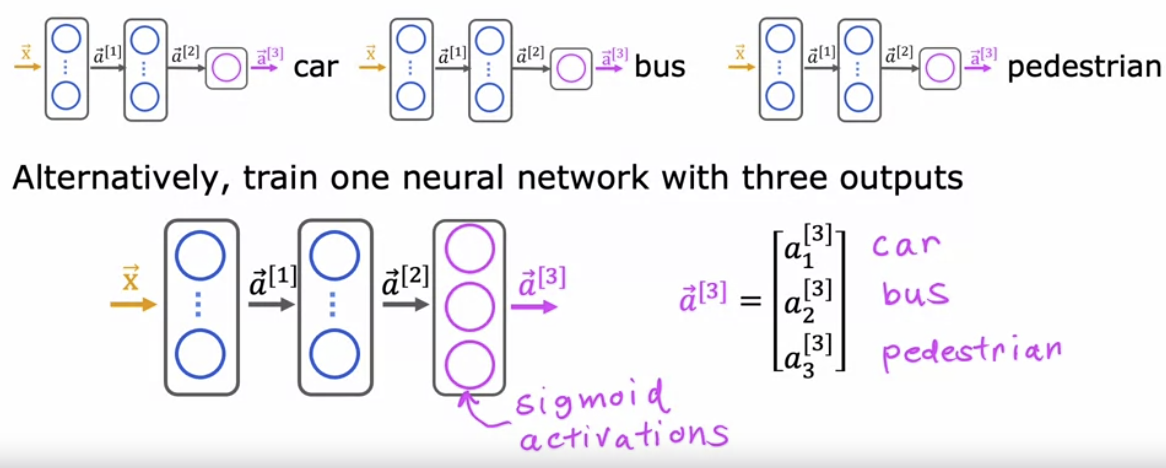

In the example below, the outputs are vecotrs instead of scalar values.

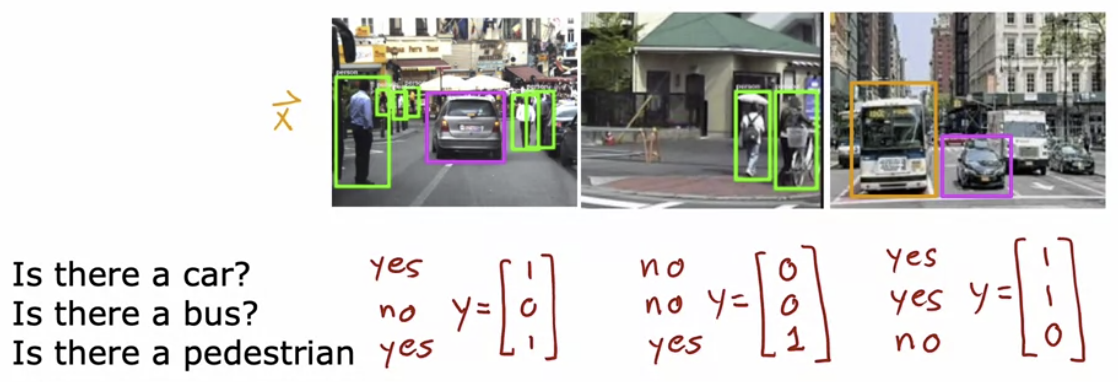

<br><br>
# 2 - Softmax Lab

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./lib/deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from IPython.display import display, Markdown, Latex
from sklearn.datasets import make_blobs
%matplotlib widget
from matplotlib.widgets import Slider
from lib.lab_utils_common import dlc
from lib.lab_utils_softmax import plt_softmax
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [4]:
def my_softmax(z):
    ez = np.exp(z)              #element-wise exponenial
    sm = ez/np.sum(ez)
    return(sm)

### Vizualization, it always adds to 1

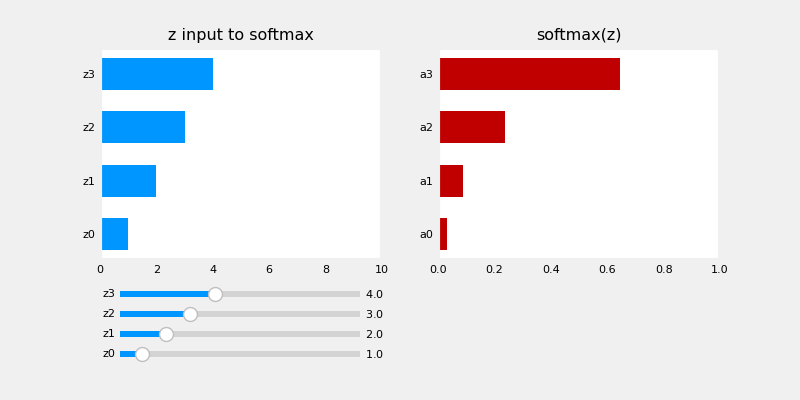

In [7]:
plt.close("all")
plt_softmax(my_softmax)

In [8]:
# DATASET

centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
X_train, y_train = make_blobs(n_samples=2000, centers=centers, cluster_std=1.0,random_state=30)

## Wrong way to implement Softmax

> This approach leads to less precission. See below for prefered approach.

In [9]:
# Wrong way to implement

model = Sequential(
    [ 
        Dense(25, activation = 'relu'),
        Dense(15, activation = 'relu'),
        Dense(4, activation = 'softmax')    # < softmax activation here
    ]
)
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
)

model.fit(
    X_train,y_train,
    epochs=10
)

Epoch 1/10


I0000 00:00:1729690432.768290   76290 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1729690432.869284   76290 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1729690432.869426   76290 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1729690432.871080   76290 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

 8/63 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - loss: 1.4529

I0000 00:00:1729690434.362233   79935 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.1919 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step - loss: 0.5816
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - loss: 0.3440
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step - loss: 0.1619
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step - loss: 0.0873
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - loss: 0.0650
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step - loss: 0.0644
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - loss: 0.0509
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step - loss: 0.0432
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step - loss: 0.0403


In [11]:
p_nonpreferred = model.predict(X_train)
print(p_nonpreferred [:2])
print("largest value", np.max(p_nonpreferred), "smallest value", np.min(p_nonpreferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step
[[5.37e-03 9.12e-03 9.64e-01 2.18e-02]
 [9.93e-01 6.87e-03 1.18e-04 2.01e-05]]
largest value 0.9999989 smallest value 2.0595543e-09


## Preferred approach

> NOTE: Last layer activation is set to `linear`.

> NOTE: Compilation loss function has `from_logits = True`.

In [12]:
preferred_model = Sequential(
    [ 
        Dense(25, activation = 'relu'),
        Dense(15, activation = 'relu'),
        Dense(4, activation = 'linear')   #<-- Note
    ]
)
preferred_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  #<-- Note
    optimizer=tf.keras.optimizers.Adam(0.001),
)

preferred_model.fit(
    X_train,y_train,
    epochs=10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.5336
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - loss: 0.7782
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step - loss: 0.3083
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step - loss: 0.1297
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 339us/step - loss: 0.0871
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step - loss: 0.0611
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step - loss: 0.0627
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step - loss: 0.0448
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - loss: 0.0425
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - loss: 0.0441


### Handling output

In this approach, outputs are not probabilitites.

In [13]:
p_preferred = preferred_model.predict(X_train)
print(f"two example output vectors:\n {p_preferred[:2]}")
print("largest value", np.max(p_preferred), "smallest value", np.min(p_preferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
two example output vectors:
 [[-3.36 -3.14  4.23  0.75]
 [ 6.2   1.19 -2.51 -5.63]]
largest value 13.525514 smallest value -14.103257


In [14]:
# Use Softmax to process into probabilitites

sm_preferred = tf.nn.softmax(p_preferred).numpy()
print(f"two example output vectors:\n {sm_preferred[:2]}")
print("largest value", np.max(sm_preferred), "smallest value", np.min(sm_preferred))

two example output vectors:
 [[4.90e-04 6.12e-04 9.69e-01 2.99e-02]
 [9.93e-01 6.65e-03 1.64e-04 7.21e-06]]
largest value 0.99999857 smallest value 1.0022512e-12


The most likely category can still be found without softmax.

In [15]:
for i in range(5):
    print( f"{p_preferred[i]}, category: {np.argmax(p_preferred[i])}")

[-3.36 -3.14  4.23  0.75], category: 2
[ 6.2   1.19 -2.51 -5.63], category: 0
[ 4.48  1.21 -2.01 -4.56], category: 0
[-2.17  3.87 -2.62 -2.32], category: 1
[-0.79 -3.61  5.03 -2.  ], category: 2
